## Installation of Required Libraries

In [1]:
!pip install --upgrade pip
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install shimmy
!pip install pandas numpy matplotlib seaborn
!pip install tqdm

print("--------------------------------------------------")
print("All installations are complete!")

--------------------------------------------------
All installations are complete!


## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Data Loading

In [3]:
file_path = 'horizontal_crop_vertical_year_report_2003_23.xls'
raw_data = pd.read_html(file_path)
if isinstance(raw_data, list):
    if raw_data:
        raw_data = raw_data[0]
    else:
        raise ValueError("No tables found in the HTML file.")

def flatten_headers(df):
    new_cols = []
    for col in df.columns:
        parts = [str(p) for p in col if 'Unnamed' not in str(p) and 'nan' not in str(p).lower()]
        joined_name = "_".join(parts).strip()
        new_cols.append(joined_name)
    df.columns = new_cols
    return df

df = flatten_headers(raw_data)

df = df.dropna(how='all').reset_index(drop=True)

print("Dataset Loaded Successfully!")
print(f"Shape of Data: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst 5 Column Names (Flattened):")
print(df.columns[:10].tolist())
print("\nPreview of the Data:")
df.head()

Dataset Loaded Successfully!
Shape of Data: 9447 rows and 291 columns

First 5 Column Names (Flattened):
['State_State_State', 'District_District_District', 'Year_Year_Year', 'Arecanut_Whole Year_Area (Hectare)', 'Arecanut_Whole Year_Production (Tonnes)', 'Arecanut_Whole Year_Yield (Tonne/Hectare)', 'Whole Year_Area (Hectare)', 'Whole Year_Production (Tonnes)', 'Whole Year_Yield (Tonne/Hectare)', 'Black pepper_Whole Year_Area (Hectare)']

Preview of the Data:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,State_State_State,District_District_District,Year_Year_Year,Arecanut_Whole Year_Area (Hectare),Arecanut_Whole Year_Production (Tonnes),Arecanut_Whole Year_Yield (Tonne/Hectare),Whole Year_Area (Hectare),Whole Year_Production (Tonnes),Whole Year_Yield (Tonne/Hectare),Black pepper_Whole Year_Area (Hectare),...,Peas (vegetable)_Whole Year_Yield (Tonne/Hectare),Other Dry Fruit_Whole Year_Area (Hectare),Other Dry Fruit_Whole Year_Production (Tonnes),Other Dry Fruit_Whole Year_Yield (Tonne/Hectare),Jute & mesta_Whole Year_Area (Hectare),Jute & mesta_Whole Year_Production (Tonnes),Jute & mesta_Whole Year_Yield (Tonne/Hectare),Total foodgrain_Whole Year_Area (Hectare),Total foodgrain_Whole Year_Production (Tonnes),Total foodgrain_Whole Year_Yield (Tonne/Hectare)
0,1. Andaman and Nicobar Islands,1. Nicobars,2003 - 2004,1261.00,1525.00,1.21,266.00,1763.00,6.63,75.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1. Andaman and Nicobar Islands,1. Nicobars,2004 - 2005,1264.70,805.85,0.64,66.42,404.12,6.08,85.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1. Andaman and Nicobar Islands,1. Nicobars,2005 - 2006,795.67,NaN,0.00,22.00,582.00,26.45,41.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1. Andaman and Nicobar Islands,1. Nicobars,2006 - 2007,896.00,477.60,0.53,198.00,976.00,4.93,22.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1. Andaman and Nicobar Islands,1. Nicobars,2010 - 2011,NaN,NaN,NaN,593.00,3425.00,5.78,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning and Crop Selection

In [4]:
df = df.rename(columns={
    'State_State_State': 'State',
    'District_District_District': 'District',
    'Year_Year_Year': 'Year'
})


In [5]:
df['Year_Start'] = df['Year'].str.extract('(\d{4})').astype(float)

annual_crops = ['Banana', 'Sugarcane', 'Potato', 'Onion', 'Rice']
tree_crops = ['Arecanut', 'Coconut', 'Cashewnut', 'Mango', 'Orange']
all_target_crops = annual_crops + tree_crops


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_24976/2424601.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Year_Start'] = df['Year'].str.extract('(\d{4})').astype(float)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
yield_cols = []
for crop in all_target_crops:
    col = [c for c in df.columns if crop in c and 'Yield' in c]
    if col:
        yield_cols.append(col[0])
clean_df = df[['State', 'District', 'Year_Start'] + yield_cols].copy()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
for col in yield_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mean())

np.random.seed(42)
crop_economics = {}
for crop in all_target_crops:
    crop_economics[crop] = {
        'Price_per_Tonne': np.random.randint(15000, 45000),
        'Cost_per_Hectare': np.random.randint(5000, 15000)
    }

print(f"Crops Selected: {all_target_crops}")
print(f"Data is now cleaned for {len(clean_df['District'].unique())} districts.")
print("\nEconomic Parameters for RL Agent (Sample):")
print(f"Banana -> Price: {crop_economics['Banana']['Price_per_Tonne']}, Cost: {crop_economics['Banana']['Cost_per_Hectare']}")

clean_df.head()

Crops Selected: ['Banana', 'Sugarcane', 'Potato', 'Onion', 'Rice', 'Arecanut', 'Coconut', 'Cashewnut', 'Mango', 'Orange']
Data is now cleaned for 692 districts.

Economic Parameters for RL Agent (Sample):
Banana -> Price: 38654, Cost: 5860


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,State,District,Year_Start,Sugarcane_Whole Year_Yield (Tonne/Hectare),Potato_Whole Year_Yield (Tonne/Hectare),Onion_Whole Year_Yield (Tonne/Hectare),Rice_Whole Year_Yield (Tonne/Hectare),Arecanut_Whole Year_Yield (Tonne/Hectare),Coconut_Whole Year_Yield (Nuts/Hectare),Cashewnut_Whole Year_Yield (Tonne/Hectare),Mango_Whole Year_Yield (Tonne/Hectare),Orange_Whole Year_Yield (Tonne/Hectare)
0,1. Andaman and Nicobar Islands,1. Nicobars,2003.0,55.554845,12.604771,11.673676,1.054107,1.210000,3750.67,0.29000,3.096033,5.431
1,1. Andaman and Nicobar Islands,1. Nicobars,2004.0,55.554845,12.604771,11.673676,1.054107,0.640000,2847.56,0.29000,3.096033,5.431
2,1. Andaman and Nicobar Islands,1. Nicobars,2005.0,55.554845,12.604771,11.673676,1.054107,0.000000,3749.49,0.12000,3.096033,5.431
3,1. Andaman and Nicobar Islands,1. Nicobars,2006.0,2.500000,12.604771,11.673676,1.054107,0.530000,4134.98,0.19000,3.096033,5.431
4,1. Andaman and Nicobar Islands,1. Nicobars,2010.0,55.554845,12.604771,11.673676,1.054107,3.276631,4896.98,7.87493,3.096033,5.431


## The Reinforcement Learning Environment

In [21]:
class CropManagementEnv(gym.Env):
    def __init__(self, data_df, economics):
        super(CropManagementEnv, self).__init__()
        self.df = data_df
        self.economics = economics
        self.crops = list(economics.keys())
        self.annual_crops = ['Banana', 'Sugarcane', 'Potato', 'Onion', 'Rice']
        self.tree_crops = ['Arecanut', 'Coconut', 'Cashewnut', 'Mango', 'Orange']

        self.action_space = spaces.Box(low=0, high=1, shape=(len(self.crops),), dtype=np.float32)

        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2 + len(self.tree_crops),), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_year = 0
        self.balance = 20000.0
        self.total_land = 100.0
        self.tree_age = np.zeros(len(self.tree_crops))
        return self._get_obs(), {}

    def _get_obs(self):
        norm_balance = self.balance / 50000.0
        norm_year = self.current_year / 20.0
        norm_tree_age = self.tree_age / 3.0
        return np.concatenate(([norm_balance, norm_year], norm_tree_age)).astype(np.float32)

    def step(self, action):
        action = np.clip(action, 0.0001, 1)
        allocation = (action / np.sum(action)) * self.total_land

        living_costs = 10000.0 * np.random.uniform(0.9, 1.1)

        year_profit = 0
        year_costs = 0

        for i, crop_name in enumerate(self.crops):
            yield_col = [c for c in self.df.columns if crop_name in c][0]
            base_yield = float(self.df[yield_col].sample(1).values[0])

            if np.random.rand() < 0.2:
                base_yield *= np.random.uniform(0.5, 1.0)

            price = self.economics[crop_name]['Price_per_Tonne'] / 100
            cost_per_unit = self.economics[crop_name]['Cost_per_Hectare'] / 100

            area = float(allocation[i])

            if crop_name in self.tree_crops:
                tree_idx = self.tree_crops.index(crop_name)
                if area > 1.0:
                    self.tree_age[tree_idx] += 1
                actual_yield = base_yield if self.tree_age[tree_idx] >= 3 else 0
            else:
                actual_yield = base_yield

            year_profit += (area * actual_yield * price)
            year_costs += (area * cost_per_unit)

        self.balance += (year_profit - year_costs - living_costs)

        if self.balance > 0:
            reward = 1.0 + (self.balance / 10000.0)
        else:
            reward = -100.0

        self.current_year += 1
        terminated = bool(self.current_year >= 20 or self.balance <= 0)
        truncated = False
        return self._get_obs(), float(reward), terminated, truncated, {}

env = CropManagementEnv(clean_df, crop_economics)
print("Environment perfectly matches Proposal and is ready for training!")

Environment perfectly matches Proposal and is ready for training!


## Training the AI Agent

In [19]:
actual_available_crop_names = []
for col_name in yield_cols:
    crop_name_part = col_name.split('_')[0]
    actual_available_crop_names.append(crop_name_part)

global all_target_crops
all_target_crops = sorted(list(set(actual_available_crop_names)))

global crop_economics
np.random.seed(42)
crop_economics = {}
for crop in all_target_crops:
    crop_economics[crop] = {
        'Price_per_Tonne': np.random.randint(15000, 45000),
        'Cost_per_Hectare': np.random.randint(5000, 15000)
    }

global env
env = CropManagementEnv(clean_df, crop_economics)

print("Environment re-initialized with corrected crop definitions.")

check_env(env)

model = PPO("MlpPolicy", env, verbose=0, learning_rate=0.0003, device="cpu")

print("Training started... Please wait a moment.")
model.learn(total_timesteps=200000, progress_bar=True)

model.save("crop_planning_model")
print("\nAI Brain trained and saved as 'crop_planning_model'!")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Environment re-initialized with corrected crop definitions.
Training started... Please wait a moment.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(



AI Brain trained and saved as 'crop_planning_model'!


## Evaluation and Visualization

--------------------------------------------------
Evaluation over 1000 simulations:
--------------------------------------------------
AI Agent: Mean Final Balance = -0.26, Bankruptcy Rate = 100.00%
Random Farmer: Mean Final Balance = 9,612.55, Bankruptcy Rate = 0.00%
Traditional Farmer: Mean Final Balance = 9,555.06, Bankruptcy Rate = 0.00%
--------------------------------------------------


/tmp/ipykernel_24976/2924562550.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, patch_artist=True,
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


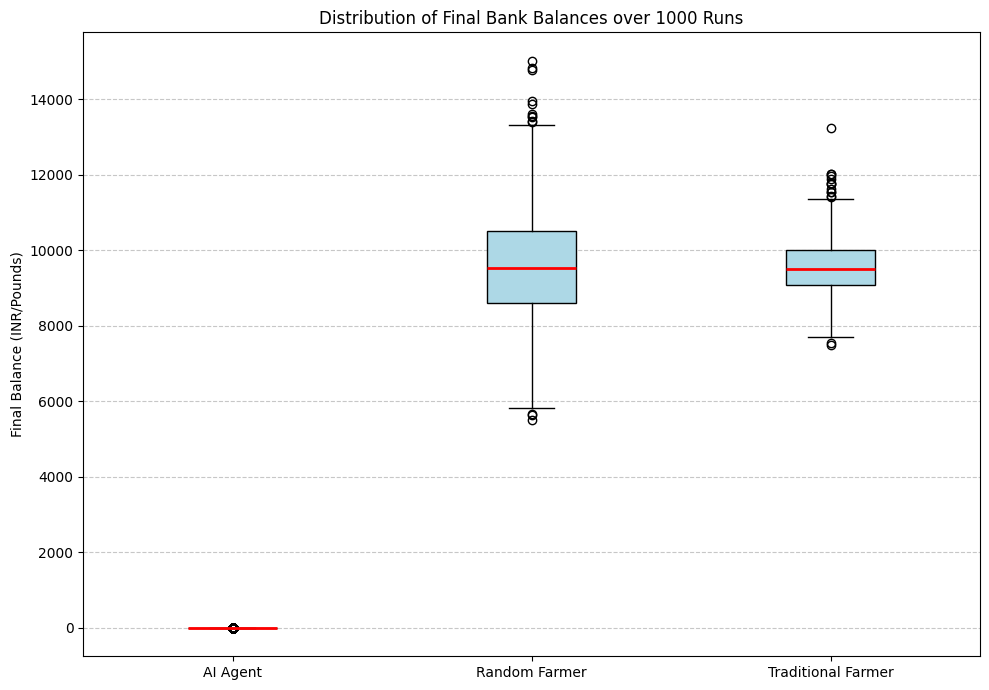

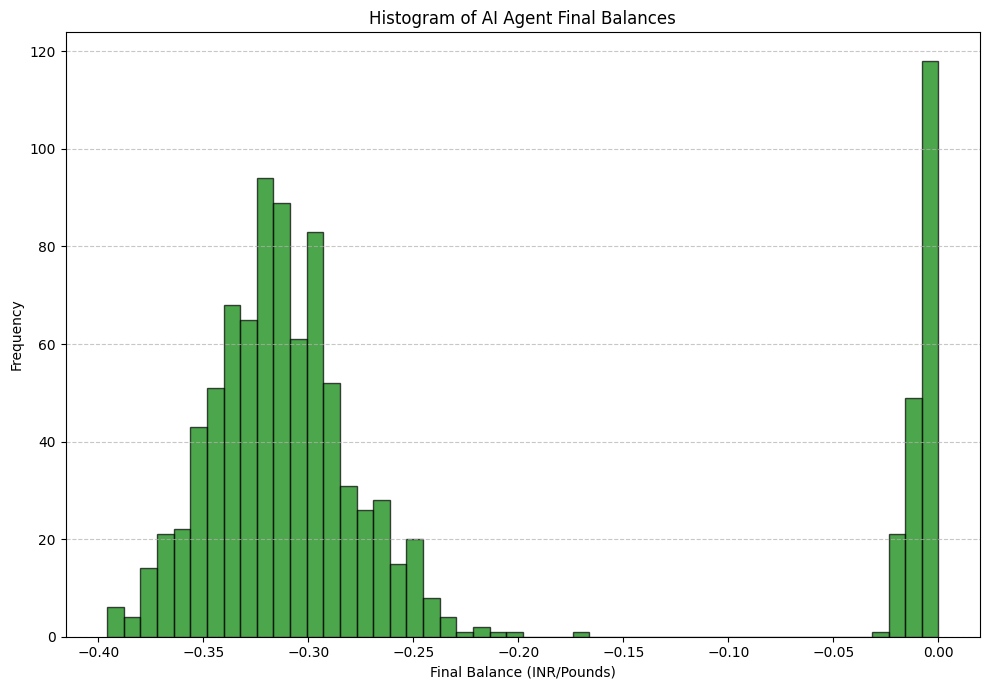

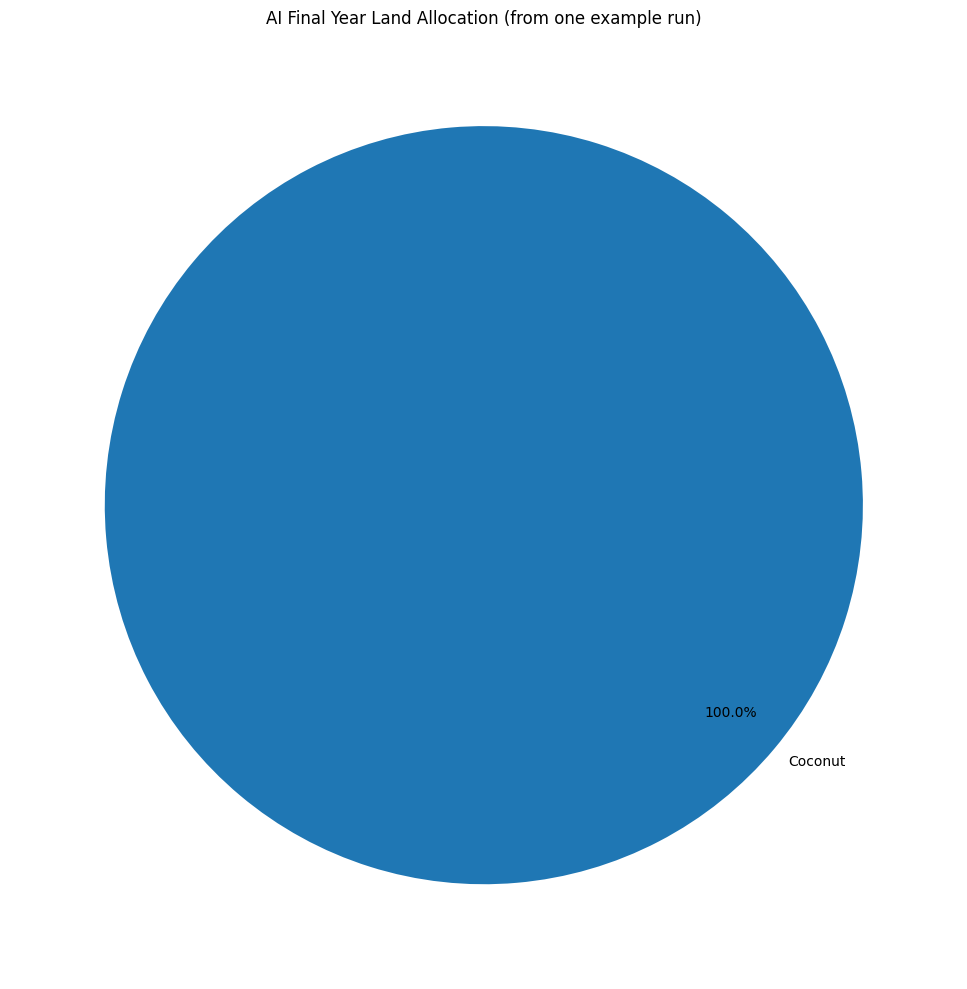

In [20]:
num_eval_runs = 1000

ai_final_balances = []
random_final_balances = []
traditional_final_balances = []

traditional_action = np.ones(env.action_space.shape[0]) / env.action_space.shape[0]
traditional_allocation = (traditional_action / np.sum(traditional_action)) * env.total_land

for run in range(num_eval_runs):
    obs, _ = env.reset()
    current_balance_ai = env.balance
    for year in range(20):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated:
            break
    ai_final_balances.append(obs[0])

    obs_r, _ = env.reset()
    current_balance_rand = env.balance
    for year in range(20):
        random_action = env.action_space.sample()
        obs_r, _, term_r, _, _ = env.step(random_action)
        if term_r:
            break
    random_final_balances.append(obs_r[0])

    obs_t, _ = env.reset()
    current_balance_trad = env.balance
    for year in range(20):
        obs_t, _, term_t, _, _ = env.step(traditional_action)
        if term_t:
            break
    traditional_final_balances.append(obs_t[0])

ai_final_balances = np.array(ai_final_balances)
random_final_balances = np.array(random_final_balances)
traditional_final_balances = np.array(traditional_final_balances)

ai_bankruptcy_rate = np.mean(ai_final_balances <= 0) * 100
random_bankruptcy_rate = np.mean(random_final_balances <= 0) * 100
traditional_bankruptcy_rate = np.mean(traditional_final_balances <= 0) * 100

print("--------------------------------------------------")
print(f"Evaluation over {num_eval_runs} simulations:")
print("--------------------------------------------------")
print(f"AI Agent: Mean Final Balance = {np.mean(ai_final_balances):,.2f}, Bankruptcy Rate = {ai_bankruptcy_rate:.2f}%")
print(f"Random Farmer: Mean Final Balance = {np.mean(random_final_balances):,.2f}, Bankruptcy Rate = {random_bankruptcy_rate:.2f}%")
print(f"Traditional Farmer: Mean Final Balance = {np.mean(traditional_final_balances):,.2f}, Bankruptcy Rate = {traditional_bankruptcy_rate:.2f}%")
print("--------------------------------------------------")

plt.figure(figsize=(10, 7))
data_to_plot = [ai_final_balances, random_final_balances, traditional_final_balances]
labels = ['AI Agent', 'Random Farmer', 'Traditional Farmer']
plt.boxplot(data_to_plot, labels=labels, patch_artist=True,
            boxprops=dict(facecolor='lightblue', edgecolor='black'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Distribution of Final Bank Balances over 1000 Runs')
plt.ylabel('Final Balance (INR/Pounds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
plt.hist(ai_final_balances, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Histogram of AI Agent Final Balances')
plt.xlabel('Final Balance (INR/Pounds)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


obs, _ = env.reset()
history_allocation = []
for year in range(20):
    action, _states = model.predict(obs, deterministic=True)
    allocation = (action / np.sum(action)) * 100
    history_allocation.append(allocation)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated:
        break

final_alloc_single_run = history_allocation[-1]
non_zero_indices = final_alloc_single_run > 0.01
filtered_allocations = final_alloc_single_run[non_zero_indices]
filtered_labels = np.array(all_target_crops)[non_zero_indices]

plt.figure(figsize=(10, 10))
plt.pie(filtered_allocations, labels=filtered_labels, autopct='%1.1f%%', startangle=140,
        pctdistance=0.85, labeldistance=1.05, textprops={'fontsize': 10})
plt.title('AI Final Year Land Allocation (from one example run)')
plt.tight_layout()
plt.show()
